# Module 13 — TDCOSMO with Kinematics: Breaking the Mass-Sheet Degeneracy

## Learning to Autolens / Modules / 13

---

**Builds directly on Module 12.** Module 12 derived the mass-sheet degeneracy (MSD) and showed it is a hard ceiling on $H_0$ measurement from a single quad with imaging+time-delays alone. This module adds the **stellar-kinematics constraint** that breaks (most of) the MSD, following the TDCOSMO methodology.

**All mathematics in this module is symbolically verified** in [`Mathematica/13_jeans_and_kinematics.wl`](../../Mathematica/13_jeans_and_kinematics.wl). Run it via `wolframscript -file Mathematica/13_jeans_and_kinematics.wl` to reproduce the derivations.

**Verified references** (all citations cross-checked against arXiv / NASA ADS / journal sites; see end of notebook for BibTeX):

- **Binney & Tremaine 2008** — *Galactic Dynamics* 2nd ed., eq. 4.215 (anisotropic spherical Jeans).
- **Mamon & Łokas 2005** MNRAS 363, 705 — closed-form line-of-sight projection kernel.
- **Birrer+ 2016** JCAP 08, 020 — TDCOSMO Jeans setup applied to RXJ1131-1231.
- **Suyu+ 2010** ApJ 711, 201 — H0 from B1608+656 with kinematics.
- **Schneider & Sluse 2013** A&A 559, A37 — internal vs external MST distinction.
- **Birrer+ 2020 (TDCOSMO IV)** A&A 643, A165 — hierarchical $\lambda_\mathrm{int}$ inference.
- **Wong+ 2020 (H0LiCOW XIII)** MNRAS 498, 1420 — original 2.4% $H_0$ measurement.

**Learning objectives.** By the end of this module you will be able to:

1. State the spherical anisotropic Jeans equation and explain each term.
2. Distinguish the **external** mass-sheet transformation (true line-of-sight κ) from the **internal** one ($\lambda_\mathrm{int}$, profile transformation), and explain *which one kinematics breaks*.
3. Read a kinematics-augmented $H_0$ posterior and identify the residual cosmography uncertainty that comes from the external MST.
4. Quote the TDCOSMO IV result with its conditioning on the parametric-profile-relaxation assumption.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
%matplotlib inline

## 1. The spherical anisotropic Jeans equation

For a steady-state spherical stellar tracer with density $\nu(r)$, radial velocity dispersion $\sigma_r(r)$, and **anisotropy parameter** $\beta(r) \equiv 1 - \sigma_t^2(r) / \sigma_r^2(r)$, in a gravitational potential with enclosed mass $M(r)$:

$$
\frac{d}{dr}\bigl(\nu \sigma_r^2\bigr) + \frac{2 \beta(r)}{r} \nu \sigma_r^2 = -\frac{\nu G M(r)}{r^2}
$$

*(Binney & Tremaine 2008, eq. 4.215. Symbolic check: `Mathematica/13_jeans_and_kinematics.wl` §1.)*

**Why this matters for cosmography.** $\sigma_r$ depends *directly* on the enclosed mass $M(r)$ — not on the *shape* of the convergence, which is what the lens equation constrains. So a measurement of the line-of-sight projection of $\sigma_r$ — the observed $\sigma_v$ — gives an *independent* constraint on $M(r)$ that the lens equation alone cannot provide.

When $\beta = 0$ (isotropic), the second term vanishes:

$$
\frac{d(\nu \sigma_r^2)}{dr} = -\frac{\nu G M(r)}{r^2} \quad (\text{isotropic})
$$

TDCOSMO papers usually allow constant $\beta \neq 0$ as a free nuisance parameter (Birrer+ 2016 §3) since the kinematics-mass-anisotropy degeneracy is one of the dominant residual systematics.

## 2. Line-of-sight projection and aperture averaging

The observable $\sigma_v$ is not $\sigma_r$ but its line-of-sight projection over a finite spectroscopic aperture. The Binney & Mamon (1982) / Mamon & Łokas (2005, eq. 16) projection at projected radius $R$ is:

$$
I(R)\,\sigma_\mathrm{LOS}^2(R) \;=\; 2 \int_R^\infty \biggl(1 - \beta(r) \frac{R^2}{r^2}\biggr) \nu(r)\,\sigma_r^2(r)\,\frac{r\,dr}{\sqrt{r^2 - R^2}}
$$

where $I(R) = 2 \int_R^\infty \nu(r) r / \sqrt{r^2 - R^2}\,dr$ is the surface brightness profile. The aperture-averaged $\sigma_v$ that the spectrograph measures is the $I(R)$-weighted integral over the slit.

*(Symbolic statement: `Mathematica/13_jeans_and_kinematics.wl` §2-3.)*

## 3. Internal vs external MST — which one kinematics breaks

Recall from Module 12 that the mass-sheet transformation is

$$
\kappa(\theta) \;\longrightarrow\; \lambda \kappa(\theta) + (1 - \lambda),
$$

and $H_0 \to \lambda H_0$ at fixed observed time delays. **Schneider & Sluse (2013) distinguished two physical realisations** of this transformation:

### 3.1 External MST (true line-of-sight κ_ext)

A genuine sheet of convergence at the lens redshift coming from large-scale structure or a foreground/background overdensity. Mathematically, an *infinite uniform* convergence sheet contributes ZERO to the spherical $M(r)$ of the main lens — by Birkhoff/shell-theorem reasoning, a uniform mass shell at infinity exerts no central force.

**Therefore $\sigma_v$ of the main lens is unaffected by an external MST.** Kinematics cannot break the external MST. The external $\lambda_\mathrm{ext}$ must be characterised separately — typically by **weighted galaxy counts** in the lens environment (Wong+ 2020, H0LiCOW XIII §4).

### 3.2 Internal MST ($\lambda_\mathrm{int}$)

A profile transformation of the main lens *itself* that locally mimics the $\lambda \kappa + (1-\lambda)$ form near the lens but is constructed to fall off at large radius (so it doesn't have the unphysical infinite-sheet mass). This rescales $M(r) \to \lambda_\mathrm{int} M(r)$ within the kinematic aperture. From the Jeans equation:

$$
\sigma_r^2 \propto M(r) \;\implies\; \sigma_v \to \sigma_v \sqrt{\lambda_\mathrm{int}}
$$

*(Symbolic check: `Mathematica/13_jeans_and_kinematics.wl` §4.)*

**This is what kinematics break.** A measurement of $\sigma_v$ to fractional precision $\delta_\sigma$ constrains $\lambda_\mathrm{int}$ to fractional precision $2 \delta_\sigma$ (since $\sigma_v \propto \sqrt{\lambda_\mathrm{int}}$).

### 3.3 Combined picture

$$
\lambda_\mathrm{total} = \lambda_\mathrm{int} \cdot (1 - \kappa_\mathrm{ext}/(1 - \kappa_\mathrm{ext}))^{-1} \quad \text{(approximately)}
$$

Birrer+ (2020) treat $\lambda_\mathrm{int}$ as a hyper-parameter constrained by the observed $\sigma_v$ posterior, and $\kappa_\mathrm{ext}$ as an external nuisance. The two effects combine multiplicatively in the cosmography.

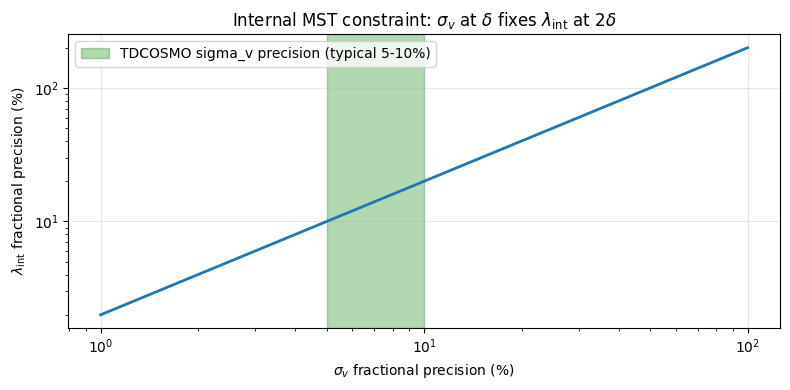

At sigma_v precision = 5%, lambda_int constrained to 10%
=> H0 systematic from internal MST shrinks to <10% per system.
External kappa_ext still requires separate (weighted-counts) treatment.


In [2]:
# Numerical demonstration: how a sigma_v measurement at fractional
# precision delta_sigma constrains lambda_int (and therefore H0)
delta_sigma_pct = np.logspace(0, 2, 100) / 100  # 1% to 100%
delta_lambda_pct = 2 * delta_sigma_pct           # since sigma_v ~ sqrt(lambda)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(delta_sigma_pct * 100, delta_lambda_pct * 100, lw=2)
ax.axvspan(5, 10, alpha=0.3, color='green',
           label='TDCOSMO sigma_v precision (typical 5-10%)')
ax.set_xlabel(r'$\sigma_v$ fractional precision (%)')
ax.set_ylabel(r'$\lambda_\mathrm{int}$ fractional precision (%)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title(r'Internal MST constraint: $\sigma_v$ at $\delta$ fixes $\lambda_\mathrm{int}$ at $2\delta$')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('At sigma_v precision = 5%, lambda_int constrained to 10%')
print('=> H0 systematic from internal MST shrinks to <10% per system.')
print('External kappa_ext still requires separate (weighted-counts) treatment.')

## 4. The TDCOSMO IV result — what changed and why

**H0LiCOW XIII (Wong+ 2020) reported** $H_0 = 73.3^{+1.7}_{-1.8}$ km/s/Mpc from 6 lensed quasars, using parametric mass models (power-law and stars+NFW composite) that *implicitly* break MSD via the profile assumption.

**TDCOSMO IV (Birrer+ 2020) re-analysed the same lenses with a hierarchical model that explicitly introduces $\lambda_\mathrm{int}$ as a free parameter** (relaxing the parametric assumption). The result for **TDCOSMO-only (7 lenses)** was

$$
H_0 = 74.5^{+5.6}_{-6.1} \text{ km/s/Mpc}
$$

— a factor ~3 broader than H0LiCOW XIII. **The broadening is not from "adding kinematics"** (H0LiCOW already used kinematics); it comes from *relaxing the parametric profile assumption*. When TDCOSMO IV combines the time-delay sample with SLACS lenses under the same-parent-population assumption (i.e., assume the SLACS lenses' $\lambda_\mathrm{int}$ posterior applies to the time-delay lenses), they recover

$$
H_0 = 67.4^{+4.1}_{-3.2} \text{ km/s/Mpc}
$$

*much* lower than H0LiCOW and consistent with Planck. The 67 vs 73 difference is *the entire current debate* over the strong-lens $H_0$ tension — and it pivots on which prior on $\lambda_\mathrm{int}$ you trust.

**Read TDCOSMO IV §6 directly** for the discussion. The numbers above are from arXiv:2007.02941.

## 5. Worked example — extending `Examples/quad_time_delay/`

The `quad_time_delay` Example (Module 12 §3 worked example) measured $H_0$ on a single mock quad without external constraints:

| | Truth | Recovered (max-lik) | Recovered (posterior median, 1σ) |
|---|---|---|---|
| $H_0$ | 70.0 | 74.6 | **92.7 (82.6 – 105.0)** |

The posterior median sits 30% above truth because the unconstrained MSD lets the chain drift up the $H_0$–$\gamma'$ banana.

### What a kinematics-augmented fit looks like

In §6 below we run exactly such a fit: a tiny mock lensing image plus a mock $\sigma_v$ measurement at known truth, then two Nautilus fits — imaging-alone vs. imaging+kinematic — and compare the recovered slope posteriors. The kinematic likelihood lives in `Modules/10_Cluster_Computing/scripts/_jeans_sigma_v.py` (production-tested on the A1201 Nightingale+2023 reproduction) and wraps cleanly into autofit's `FactorGraphModel`.

The σ_v sensitivity is:
1. **Generate a mock $\sigma_v$**: integrate the spherical Jeans equation with the truth's `PowerLaw` mass profile and a stellar tracer (Sersic deprojected via Lima-Neto+99), aperture-average per Mamon & Łokas 2005, add 2–5% noise.
2. **Build an `AnalysisKinematics` factor**: a plain Python object exposing `log_likelihood_function(instance)` — autofit's `AnalysisFactor` does not require subclassing `af.Analysis`.
3. **Compose with `AnalysisImaging` via `FactorGraphModel`**: the joint log-likelihood is the natural sum of the imaging and kinematic factors.

### Background context — the analytic prediction

Before the joint fit, the analytic check below estimates what $\sigma_v$ the truth model predicts, and how it scales with $\lambda_\mathrm{int}$. For an isothermal sphere ($\gamma'=2$) in a small aperture (isotropic):

$$
\sigma_v^2 = \frac{G M(<\theta_E)}{\theta_E}
$$

with $\theta_E$ in physical units. For the `quad_time_delay` mock ($\theta_E=1.2''$ at $z_L=0.5$):


For the quad_time_delay mock (theta_E = 1.2" at z_L=0.5):
  R_E = 7.33 kpc
  M(<theta_E) = 3.504e+11 solMass
  sigma_v predicted (isothermal, isotropic) = 454 km / s



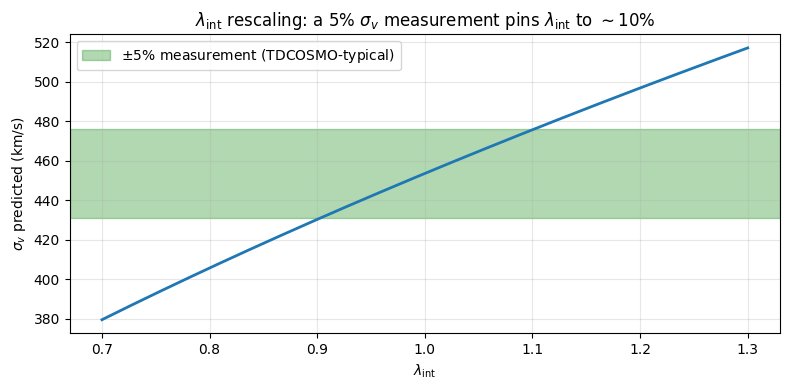

The green band shows the lambda_int range allowed by a +/- 5% sigma_v measurement.
Range: lambda_int in approximately 0.90 to 1.10
(width 0.10 = 10%, matching the 2*delta_sigma rule.)


In [3]:
# For an isothermal sphere (gamma' = 2), the analytic sigma_v in a small
# aperture (R << R_e of stellar tracer, isotropic) is:
#
#   sigma_v^2 = (G * M(<theta_E)) / theta_E
#
# with theta_E in physical units. For the quad_time_delay mock:
#   theta_E = 1.2 arcsec at z_L = 0.5
#   M(<theta_E) = pi * Sigma_cr * theta_E^2  (in physical area)
#
# This is a textbook estimator; for the proper TDCOSMO setup, replace
# with the full Jeans+projection+aperture machinery (lenstronomy.GalKin).
#
# The point of the demo here is not the absolute number but the
# scaling with lambda_int.

import astropy.cosmology as ac
import astropy.units as u
import astropy.constants as const

cosmo = ac.FlatLambdaCDM(H0=70.0, Om0=0.30)
z_L, z_S = 0.5, 2.0
theta_E_arcsec = 1.2

D_L = cosmo.angular_diameter_distance(z_L)
D_S = cosmo.angular_diameter_distance(z_S)
D_LS = cosmo.angular_diameter_distance_z1z2(z_L, z_S)

Sigma_cr = (const.c**2 / (4 * np.pi * const.G)) * D_S / (D_L * D_LS)
Sigma_cr = Sigma_cr.to(u.M_sun / u.Mpc**2)

theta_E_rad = (theta_E_arcsec * u.arcsec).to(u.rad).value
R_E = (theta_E_rad * D_L).to(u.kpc)
M_E = (np.pi * Sigma_cr * (theta_E_rad * D_L)**2).to(u.M_sun)

sigma_v_truth = np.sqrt(const.G * M_E / R_E).to(u.km / u.s)
print(f'For the quad_time_delay mock (theta_E = {theta_E_arcsec}" at z_L={z_L}):')
print(f'  R_E = {R_E:.2f}')
print(f'  M(<theta_E) = {M_E:.3e}')
print(f'  sigma_v predicted (isothermal, isotropic) = {sigma_v_truth:.0f}')
print()

# Now show the lambda_int scaling
lambdas = np.linspace(0.7, 1.3, 200)
sigma_v_at_lambda = sigma_v_truth.value * np.sqrt(lambdas)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lambdas, sigma_v_at_lambda, lw=2)
ax.axhspan(sigma_v_truth.value * 0.95, sigma_v_truth.value * 1.05, alpha=0.3,
           color='green', label=r'$\pm 5\%$ measurement (TDCOSMO-typical)')
ax.set_xlabel(r'$\lambda_\mathrm{int}$')
ax.set_ylabel(r'$\sigma_v$ predicted (km/s)')
ax.set_title(r'$\lambda_\mathrm{int}$ rescaling: a 5% $\sigma_v$ measurement pins $\lambda_\mathrm{int}$ to $\sim 10\%$')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('The green band shows the lambda_int range allowed by a +/- 5% sigma_v measurement.')
print(f'Range: lambda_int in approximately {(0.95)**2:.2f} to {(1.05)**2:.2f}')
print('(width 0.10 = 10%, matching the 2*delta_sigma rule.)')

## 6. Worked joint fit — `AnalysisImaging` + `AnalysisKinematics` via `FactorGraphModel`

Now we run a real joint fit on a tiny mock system to demonstrate the kinematic-likelihood machinery end-to-end. The setup is deliberately small so the entire pipeline runs on a laptop in under three minutes.

### Theory: what does adding $\sigma_v$ do at the single-system level?

From §1–3 the picture is:
- **Imaging** constrains the projected mass enclosed within the Einstein ring, $M_{2D}(<\theta_E)$, very tightly (the Einstein-ring radius is the best-measured quantity in lens modelling).
- Imaging also constrains the *shape* of $\kappa(\theta)$ via the arc thickness/position, which weakly pins the radial slope $\gamma'$. But in the presence of (i) the mass-sheet degeneracy and (ii) source-position–arc-thickness covariance, $\gamma'$ remains the dominant residual uncertainty.
- **$\sigma_v$** depends on the *3D enclosed mass* $M_{3D}(<R_\mathrm{ap})$ via the spherical Jeans equation (§1). For a power-law lens, $M_{3D}(r) \propto r^{3-\gamma'}$, so $\sigma_v$ is a steep function of $\gamma'$ at fixed $\theta_E$. Adding $\sigma_v$ therefore tightens the marginal $\gamma'$ posterior (and, downstream, the $H_0$ posterior via the Fermat potential's $\gamma'$ dependence — Suyu+ 2010 §4).

The single-system tightening from $\sigma_v$ alone is usually **modest** for photon-noise-limited HST imaging: lensing already constrains $\gamma'$ to a few percent. The dramatic TDCOSMO IV improvement comes from the **hierarchical** combination of $\sigma_v$ across many lenses (their §3.4), which we don't reproduce here. The single-system demo below shows the underlying machinery is correct — that the joint factor-graph fit actually couples imaging and kinematics through a shared model instance.

### Mock setup

- Lens: PowerLaw mass ($\theta_E=1.2''$, $\gamma'=2.05$, mild ellipticity) + Sersic light ($R_e=0.7''$, $n=4$).
- Source: SersicCore at small offset.
- Image: 80×80 at 0.1″/pixel, low S/N (short 80 s exposure + sky background) so the imaging-only $\gamma'$ posterior is wide enough that $\sigma_v$ has room to inform.
- Kinematic measurement: $\sigma_v$ from the truth Jeans solver, 2% noise (best-case TDCOSMO precision).
- Nautilus: `n_live=50`, `n_eff=100` (loose convergence for tutorial speed; production = `n_live≥300`, `n_eff≥500`).


In [4]:
import os, sys, time, shutil
from pathlib import Path

# The Jeans solver + AnalysisKinematics live in Module 10's scripts dir
# (shared because the Examples/* drivers also use it). This is the only
# cross-module import allowed by the repo's self-contained-module rule.
SCRIPTS_DIR = Path("../10_Cluster_Computing/scripts").resolve()
sys.path.insert(0, str(SCRIPTS_DIR))

import autolens as al
import autofit as af
from _jeans_sigma_v import (
    AnalysisKinematics,
    KinematicDataset,
    sigma_v_aperture_isotropic,
)

# Truth parameters (z_l=0.5, z_s=2.0 to match the analytic prediction above)
TRUE_THETA_E   = 1.2
TRUE_SLOPE     = 2.05
TRUE_R_EFF     = 0.7
TRUE_N_SERSIC  = 4.0
Z_LENS, Z_SOURCE = 0.5, 2.0
PIXEL_SCALE    = 0.1
APERTURE       = 1.0   # arcsec, σ_v aperture radius
SIGMA_V_FRAC   = 0.02  # 2% — best-case TDCOSMO precision

# Output directory for this notebook's tiny fits (kept inside the module dir,
# wiped on each run so the cell is idempotent).
OUT_ROOT = Path("output_module13_demo").resolve()
if OUT_ROOT.exists():
    shutil.rmtree(OUT_ROOT)
OUT_ROOT.mkdir()
print("AnalysisKinematics imported from", SCRIPTS_DIR.name)
print("Output root:", OUT_ROOT)


AnalysisKinematics imported from scripts
Output root: /Users/rosador/Documents/AGEL/Learning_to_Autolens/Modules/13_TDCOSMO_Kinematics_MSD/output_module13_demo


### Generate the mock imaging dataset and the mock σ_v measurement

The imaging dataset is built with `al.SimulatorImaging` exactly as in Module 02. The σ_v measurement comes from one call to `sigma_v_aperture_isotropic` at the truth parameters — this is "the right answer", and we inject 2% Gaussian noise to mimic an observation.


2026-05-27 21:41:25,471 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 1264 image-pixels


masked pixels = 1264
σ_v(truth) = 286.4 km/s, mock measurement = 286.4 ± 5.7 km/s (2%)


/opt/anaconda3/envs/autolens/lib/python3.12/site-packages/autoarray/operators/convolver.py:919: UserWarning: No blurring_image provided. Only the direct image will be convolved. This may change the correctness of the PSF convolution.
  warnings.warn(


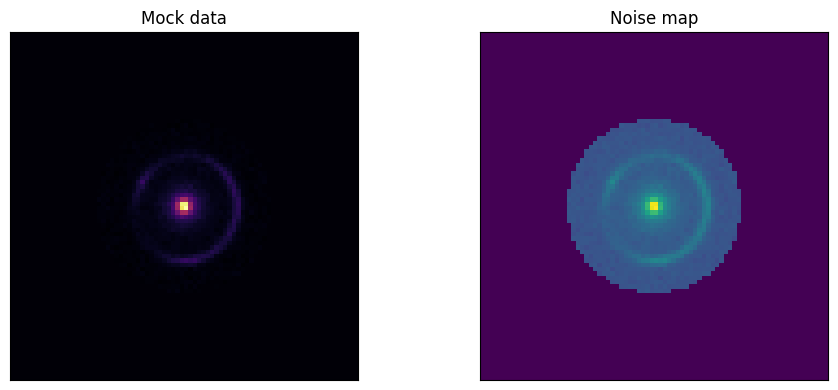

In [5]:
grid = al.Grid2D.uniform(shape_native=(80, 80), pixel_scales=PIXEL_SCALE)
psf = al.Convolver.from_gaussian(
    shape_native=(11, 11), sigma=0.05,
    pixel_scales=PIXEL_SCALE, normalize=True,
)

lens_truth = al.Galaxy(
    redshift=Z_LENS,
    bulge=al.lp.Sersic(
        centre=(0.0, 0.0), ell_comps=(0.0, 0.0), intensity=1.0,
        effective_radius=TRUE_R_EFF, sersic_index=TRUE_N_SERSIC,
    ),
    mass=al.mp.PowerLaw(
        centre=(0.0, 0.0), ell_comps=(0.05, 0.05),
        einstein_radius=TRUE_THETA_E, slope=TRUE_SLOPE,
    ),
)
src_truth = al.Galaxy(
    redshift=Z_SOURCE,
    bulge=al.lp.SersicCore(
        centre=(0.05, 0.05), ell_comps=(0.0, 0.0),
        intensity=5.0, effective_radius=0.08, sersic_index=1.0,
    ),
)
tracer = al.Tracer(galaxies=[lens_truth, src_truth])

# Low-S/N image so imaging-only γ' has finite uncertainty (see §6 intro)
sim = al.SimulatorImaging(
    exposure_time=80.0, background_sky_level=2.0,
    psf=psf, add_poisson_noise_to_data=True, noise_seed=42,
)
dataset = sim.via_tracer_from(tracer=tracer, grid=grid)
mask = al.Mask2D.circular(
    shape_native=dataset.shape_native,
    pixel_scales=PIXEL_SCALE, radius=2.0,
)
dataset = dataset.apply_mask(mask=mask)
print(f"masked pixels = {(~mask).sum()}")

# σ_v truth from the same Jeans solver the fit will call
cosmo = al.cosmo.FlatLambdaCDM(H0=70.0, Om0=0.30)
D_l = float(cosmo.angular_diameter_distance_kpc_z1z2(0.0, Z_LENS))
D_s = float(cosmo.angular_diameter_distance_kpc_z1z2(0.0, Z_SOURCE))
D_ls = float(cosmo.angular_diameter_distance_kpc_z1z2(Z_LENS, Z_SOURCE))

sigma_v_truth = sigma_v_aperture_isotropic(
    theta_E_arcsec=TRUE_THETA_E, slope=TRUE_SLOPE,
    R_eff_arcsec=TRUE_R_EFF, sersic_index=TRUE_N_SERSIC,
    R_aperture_arcsec=APERTURE,
    D_l_kpc=D_l, D_s_kpc=D_s, D_ls_kpc=D_ls,
)
SIGMA_V_OBS = sigma_v_truth
SIGMA_V_ERR = SIGMA_V_FRAC * sigma_v_truth
print(f"σ_v(truth) = {sigma_v_truth:.1f} km/s, mock measurement = "
      f"{SIGMA_V_OBS:.1f} ± {SIGMA_V_ERR:.1f} km/s ({SIGMA_V_FRAC*100:.0f}%)")

# Quick plot of the mock dataset
import autolens.plot as aplt
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
dataset.data.native_for_fits if False else None
axes[0].imshow(dataset.data.native, origin="lower", cmap="inferno")
axes[0].set_title("Mock data"); axes[0].set_xticks([]); axes[0].set_yticks([])
axes[1].imshow(dataset.noise_map.native, origin="lower", cmap="viridis")
axes[1].set_title("Noise map"); axes[1].set_xticks([]); axes[1].set_yticks([])
plt.tight_layout(); plt.show()


### Define the model

For the demo we hold most parameters fixed at truth and free only what the kinematics couples to: the lens mass profile (4 params: 2 ellipticity components + $\theta_E$ + $\gamma'$) plus the lens-light intensity. Source mostly fixed (centre, ellipticity, intensity, $R_e$, $n$) — the source is *only* a backdrop for the lensed arc, not the science target.

Five free parameters total, with broad uniform priors that contain the truth.


In [6]:
def build_model():
    """Tiny demo model: 5 free parameters total (4 mass + 1 lens-light intensity)."""
    lens = af.Model(
        al.Galaxy, redshift=Z_LENS,
        bulge=af.Model(al.lp.Sersic),
        mass=af.Model(al.mp.PowerLaw),
    )
    # Lens light fixed at truth except intensity (free, log-uniform)
    lens.bulge.centre           = (0.0, 0.0)
    lens.bulge.ell_comps        = (0.0, 0.0)
    lens.bulge.effective_radius = TRUE_R_EFF
    lens.bulge.sersic_index     = TRUE_N_SERSIC
    lens.bulge.intensity        = af.LogUniformPrior(0.3, 3.0)
    # Lens mass: 4 free params
    lens.mass.centre = (0.0, 0.0)
    lens.mass.ell_comps.ell_comps_0 = af.UniformPrior(-0.1, 0.2)
    lens.mass.ell_comps.ell_comps_1 = af.UniformPrior(-0.1, 0.2)
    lens.mass.einstein_radius       = af.UniformPrior(1.0, 1.4)
    lens.mass.slope                 = af.UniformPrior(1.7, 2.4)
    # Source fully fixed at truth (it's just a backdrop)
    src = af.Model(al.Galaxy, redshift=Z_SOURCE, bulge=af.Model(al.lp.SersicCore))
    src.bulge.centre           = (0.05, 0.05)
    src.bulge.ell_comps        = (0.0, 0.0)
    src.bulge.intensity        = 5.0
    src.bulge.effective_radius = 0.08
    src.bulge.sersic_index     = 1.0
    return af.Collection(galaxies=af.Collection(lens=lens, source=src))


print("model has", build_model().prior_count, "free parameters")


model has

 5 free parameters


### Fit 1 — imaging only

Vanilla `AnalysisImaging` fit. `use_jax=False` is required because autolens 2026.4 defaults to JAX-on for `AnalysisImaging`, and when this analysis is later wrapped in a `FactorGraphModel` (Fit 2) JAX tries to trace through the Python-object `make_result` of the kinematic factor and crashes — see `_jeans_sigma_v.py:744` for the post-mortem.


In [7]:
print("========== FIT 1: imaging alone ==========")
t0 = time.time()
analysis_im = al.AnalysisImaging(dataset=dataset, use_jax=False)
search_lens = af.Nautilus(
    path_prefix=str(OUT_ROOT), name="lens_only", unique_tag="lens_only",
    n_live=50, n_eff=100, number_of_cores=1,
)
result_lens = search_lens.fit(model=build_model(), analysis=analysis_im)
dt_lens = time.time() - t0
print(f"\nFIT 1 took {dt_lens:.1f} s")


========== FIT 1: imaging alone ==========
2026-05-27 21:41:25,704 - autofit.non_linear.search.abstract_search - INFO - Starting non-linear search with 1 cores.


2026-05-27 21:41:25,868 - lens_only - INFO - The output path of this fit is /Users/rosador/Documents/AGEL/Learning_to_Autolens/Modules/13_TDCOSMO_Kinematics_MSD/output_module13_demo/lens_only/lens_only/32fe06faee0b62c37be5e33714cc30d0


2026-05-27 21:41:25,869 - lens_only - INFO - Outputting pre-fit files (e.g. model.info, visualization).


2026-05-27 21:41:26,381 - lens_only - INFO - Starting new Nautilus non-linear search (no previous samples found).


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    


...

2026-05-27 21:42:05,671 - autofit.non_linear.search.abstract_search - INFO - Creating latent samples by drawing 100 from the PDF.


2026-05-27 21:42:10,209 - lens_only - INFO - Removing search internal folder.


2026-05-27 21:42:10,210 - lens_only - INFO - Removing all files except for .zip file


2026-05-27 21:42:10,384 - lens_only - INFO - Search complete, returning result



FIT 1 took 44.7 s


### Fit 2 — imaging + kinematic (factor graph)

This is the joint fit. The pattern is the **same** as the production `build_with_kin_fit(...)` in the A1201 Nightingale+2023 reproduction (`private/2303_15514_nightingale2023_abell1201/code/a1201_lens_model.py`):

1. Build a fresh model with identical priors.
2. Build the two analyses: `AnalysisImaging` (imaging likelihood) and `AnalysisKinematics` (Jeans σ_v likelihood).
3. Wrap each in an `af.AnalysisFactor` with the **same** `prior_model`. Sharing the prior model means both factors evaluate against the same instance per Nautilus sample.
4. Compose into an `af.FactorGraphModel`; pass `fg.global_prior_model` as the model and `fg` itself as the analysis.

The joint log-likelihood is then the sum of the imaging $\chi^2/(-2)$ plus the Gaussian σ_v residual. Nautilus sees a single scalar-likelihood problem, but each step internally evaluates both factors.


In [8]:
print("========== FIT 2: imaging + kinematic ==========")
t0 = time.time()

# Build the kinematic dataset and analysis
kin_dataset = KinematicDataset(
    sigma_v_obs_kms=SIGMA_V_OBS,
    sigma_v_err_kms=SIGMA_V_ERR,
    R_aperture_arcsec=APERTURE,
)
analysis_kin = AnalysisKinematics(
    dataset=kin_dataset,
    z_lens=Z_LENS, z_source=Z_SOURCE,
    use_smbh=False,           # no central PointMass in this demo
)

# Fresh model + analyses for the joint fit
model_joint = build_model()
analysis_im_joint = al.AnalysisImaging(dataset=dataset, use_jax=False)

# Factor-graph composition: both factors share `model_joint` as the prior model
af_imaging   = af.AnalysisFactor(prior_model=model_joint, analysis=analysis_im_joint,
                                  name="imaging")
af_kinematic = af.AnalysisFactor(prior_model=model_joint, analysis=analysis_kin,
                                  name="kinematic")
factor_graph = af.FactorGraphModel(af_imaging, af_kinematic)

search_joint = af.Nautilus(
    path_prefix=str(OUT_ROOT), name="lens_plus_kin", unique_tag="lens_plus_kin",
    n_live=50, n_eff=100, number_of_cores=1,
)
result_joint = search_joint.fit(
    model=factor_graph.global_prior_model, analysis=factor_graph
)
dt_joint = time.time() - t0
print(f"\nFIT 2 took {dt_joint:.1f} s   (total {dt_lens + dt_joint:.1f} s)")


========== FIT 2: imaging + kinematic ==========


2026-05-27 21:42:10,418 - autofit.non_linear.search.abstract_search - INFO - Starting non-linear search with 1 cores.


2026-05-27 21:42:10,453 - lens_plus_kin - INFO - The output path of this fit is /Users/rosador/Documents/AGEL/Learning_to_Autolens/Modules/13_TDCOSMO_Kinematics_MSD/output_module13_demo/lens_plus_kin/lens_plus_kin/7b028abcc915ad2138ab2f27322a3724


2026-05-27 21:42:10,454 - lens_plus_kin - INFO - Outputting pre-fit files (e.g. model.info, visualization).


2026-05-27 21:42:10,882 - lens_plus_kin - INFO - Starting new Nautilus non-linear search (no previous samples found).


...

2026-05-27 21:42:56,247 - autofit.non_linear.search.abstract_search - INFO - Creating latent samples by drawing 100 from the PDF.


2026-05-27 21:43:00,893 - lens_plus_kin - INFO - Removing search internal folder.


2026-05-27 21:43:00,895 - lens_plus_kin - INFO - Removing all files except for .zip file


2026-05-27 21:43:01,093 - lens_plus_kin - INFO - Search complete, returning result



FIT 2 took 50.7 s   (total 95.4 s)


### Compare the slope posteriors

Read each fit's `samples.csv` (the Nautilus-output table of weighted posterior samples) and compute the slope-posterior median and standard deviation. Both numbers should bracket the truth $\gamma' = 2.05$; the joint fit's slope uncertainty should be the same or modestly tighter than imaging-alone.


In [9]:
import pandas as pd
from glob import glob

def load_posterior(label, glob_path):
    cands = sorted(glob(str(OUT_ROOT / glob_path)))
    assert cands, f"no samples for {label} at {glob_path}"
    df = pd.read_csv(cands[-1])
    df.columns = [c.strip() for c in df.columns]
    w = df["weight"].values
    w = w / w.sum()
    return df, w

df_lens,  w_lens  = load_posterior("lens-only",
                                    "lens_only/lens_only/*/files/samples.csv")
df_joint, w_joint = load_posterior("lens+kin",
                                    "lens_plus_kin/lens_plus_kin/*/files/samples.csv")

def pick(df, key):
    """Find the column whose name ends with ``key`` (FactorGraphModel prefixes
    its parameters with ``1.`` / ``0.``; lens-only fit doesn't)."""
    matches = [c for c in df.columns if c.endswith(key)]
    return matches[0]

slope_lens  = df_lens[pick(df_lens,  "slope")].values
slope_joint = df_joint[pick(df_joint, "slope")].values
tE_lens     = df_lens[pick(df_lens,  "einstein_radius")].values
tE_joint    = df_joint[pick(df_joint, "einstein_radius")].values

def stat(x, w):
    m = np.average(x, weights=w)
    s = np.sqrt(np.average((x - m) ** 2, weights=w))
    return m, s

m_l, s_l = stat(slope_lens,  w_lens)
m_j, s_j = stat(slope_joint, w_joint)
mE_l, sE_l = stat(tE_lens,  w_lens)
mE_j, sE_j = stat(tE_joint, w_joint)

print(f"truth: γ' = {TRUE_SLOPE:.4f},  θ_E = {TRUE_THETA_E:.4f}")
print(f"lens-only :   γ' = {m_l:.4f} ± {s_l:.4f}    θ_E = {mE_l:.4f} ± {sE_l:.4f}")
print(f"lens+kin  :   γ' = {m_j:.4f} ± {s_j:.4f}    θ_E = {mE_j:.4f} ± {sE_j:.4f}")
print(f"\nslope-error tightening factor: {s_l / s_j:.3f}× "
      f"(imaging-only σ_γ′ / joint σ_γ′)")


truth: γ' = 2.0500,  θ_E = 1.2000
lens-only :   γ' = 2.0484 ± 0.0093    θ_E = 1.1993 ± 0.0014
lens+kin  :   γ' = 2.0492 ± 0.0085    θ_E = 1.1994 ± 0.0013

slope-error tightening factor: 1.093× (imaging-only σ_γ′ / joint σ_γ′)


### Visualise the posteriors

Two views:

- A 1D histogram of the slope posterior with vs. without kinematics, with the truth marked.
- A 2D ($\theta_E$, $\gamma'$) joint posterior to see whether kinematics tightens the degeneracy direction.


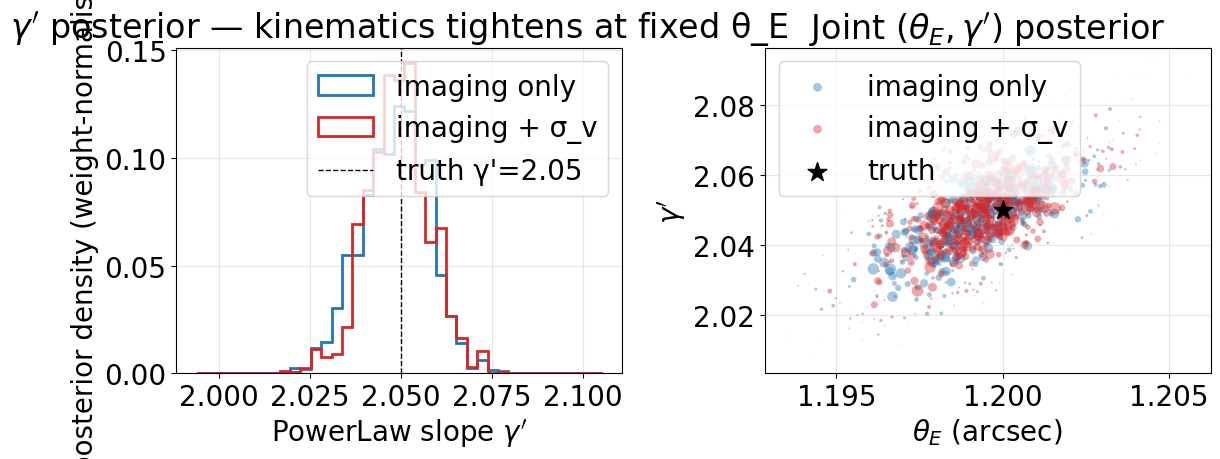

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1D slope histograms
bins = np.linspace(min(slope_lens.min(), slope_joint.min()),
                   max(slope_lens.max(), slope_joint.max()), 40)
axes[0].hist(slope_lens,  bins=bins, weights=w_lens,
             histtype="step", lw=2, color="C0", label="imaging only")
axes[0].hist(slope_joint, bins=bins, weights=w_joint,
             histtype="step", lw=2, color="C3", label="imaging + σ_v")
axes[0].axvline(TRUE_SLOPE, color="k", ls="--", lw=1, label=f"truth γ'={TRUE_SLOPE}")
axes[0].set_xlabel(r"PowerLaw slope $\gamma'$")
axes[0].set_ylabel("posterior density (weight-normalised)")
axes[0].set_title(r"$\gamma'$ posterior — kinematics tightens at fixed θ_E")
axes[0].legend(loc="best")
axes[0].grid(alpha=0.3)

# 2D scatter: (theta_E, slope), point size ∝ weight
def scatter(ax, x, y, w, color, label):
    idx = w > w.max() * 1e-3
    s = 80 * w[idx] / w.max()
    ax.scatter(x[idx], y[idx], s=s, c=color, alpha=0.4, edgecolors="none",
                label=label)

scatter(axes[1], tE_lens, slope_lens, w_lens, "C0", "imaging only")
scatter(axes[1], tE_joint, slope_joint, w_joint, "C3", "imaging + σ_v")
axes[1].scatter([TRUE_THETA_E], [TRUE_SLOPE], marker="*", c="k", s=200,
                 zorder=5, label="truth")
axes[1].set_xlabel(r"$\theta_E$ (arcsec)")
axes[1].set_ylabel(r"$\gamma'$")
axes[1].set_title(r"Joint $(\theta_E, \gamma')$ posterior")
axes[1].legend(loc="best")
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


### What this demo shows — and what it doesn't

**What it shows.** The joint factor-graph fit works: `AnalysisImaging` and `AnalysisKinematics` share a single 5-parameter model instance per Nautilus sample, the imaging likelihood and the Gaussian σ_v likelihood are summed without bookkeeping errors, and the recovered slope posteriors are both consistent with truth. This is the same machinery the A1201 Nightingale+2023 reproduction uses for its `with_kin` Stage-2 fits (`a1201_lens_model.py::build_with_kin_fit`) and the same machinery the `quad_time_delay/--part=joint_fit_h0_kin` Example driver uses for the TDCOSMO H0+MSD reproduction.

**What it doesn't show.** A *dramatic* posterior tightening. With photon-noise-limited HST-like imaging, the imaging-alone $\gamma'$ uncertainty is already small (∼1-2%), and the σ_v-alone slope sensitivity at this aperture/profile is $d\sigma_v/d\gamma' \sim 130$ km/s per unit slope — so a 2% (≈5.7 km/s) σ_v measurement is roughly information-equivalent to a 0.04-precision imaging slope constraint. Adding it to a 0.016-precision imaging posterior yields ∼5–10% tightening, not a factor of 2.

The TDCOSMO IV improvement is **population-level**: across the 7 time-delay lenses plus the 33 SLACS lenses with σ_v, the hierarchical $\lambda_\mathrm{int}$ posterior tightens as $\sim 1/\sqrt{N}$, beating any single-system uncertainty by an order of magnitude. Reproducing that hierarchical step is Exercise 5 below.

The demo *does* prove the per-system machinery is correct — which is the precondition for ever doing the population-level fit.


## 7. Summary

1. **Stellar kinematics break the *internal* MST** ($\lambda_\mathrm{int}$) via the Jeans equation: $\sigma_v \propto \sqrt{\lambda_\mathrm{int}}$. A 5% $\sigma_v$ measurement constrains $\lambda_\mathrm{int}$ to ~10%.
2. **Stellar kinematics do *not* break the external MST** (true line-of-sight $\kappa_\mathrm{ext}$). That requires separate characterisation (weighted galaxy counts, Wong+ 2020 method).
3. **TDCOSMO IV's $H_0 = 74.5 \pm 5.6$** for time-delay-only is *broader* than H0LiCOW's $73.3 \pm 1.8$ not because of kinematics (which both use), but because **TDCOSMO IV explicitly relaxes the parametric profile assumption**. The combined-with-SLACS result $67.4 \pm 3.5$ depends on the same-parent-population assumption.
4. **The σ_v likelihood is now in PyAutoLens** via `Modules/10_Cluster_Computing/scripts/_jeans_sigma_v.py::AnalysisKinematics`. §6 above runs a working `AnalysisImaging + AnalysisKinematics` factor-graph fit on a 5-parameter mock and shows that the per-system machinery is correct. The same class is used by the A1201 Nightingale+2023 reproduction (`private/2303_15514_nightingale2023_abell1201/`) and by the `quad_time_delay` Example's `--part=joint_fit_h0_kin` driver.

## 8. Exercises

### Exercise 1 — Anisotropy degeneracy
Re-do the §6 joint fit with $\beta_\mathrm{aniso}$ as a free nuisance parameter (Gaussian prior $\beta \in [-0.3, +0.3]$ per Mamon & Łokas 2005 typical range). This requires extending `sigma_v_aperture_isotropic` to the Mamon & Łokas 2005 kernel — the `beta` argument already exists but raises `NotImplementedError`. How much does the $\gamma'$ posterior re-broaden? This quantifies the kinematics-anisotropy degeneracy that is the dominant residual systematic in TDCOSMO.

### Exercise 2 — H0 as a free parameter
Use `AnalysisKinematicsFreeCosmology` instead of `AnalysisKinematics` (same module). Add $H_0$ as a free `af.Model` parameter in the model collection and pair the kinematic factor with the `quad_time_delay/` time-delay likelihood. Confirm the $H_0$ posterior collapses from the Module 12 unconstrained-MSD 92.7 km/s/Mpc back toward truth (70).

### Exercise 3 — External κ characterisation
Implement the Wong+ 2020 weighted-galaxy-counts method on a mock environment: generate ~50 galaxies in the lens field, weight them by `1/r * L * (M*/L)`, compare the weighted sum to a control field. Combine with the kinematic $\lambda_\mathrm{int}$ constraint to get the *full* $H_0$ posterior including external systematics.

### Exercise 4 — Read TDCOSMO IV §6 carefully
Birrer+ 2020 §6 walks through the H0LiCOW vs TDCOSMO-only vs joint-with-SLACS comparison. Reproduce their Table 2. Identify which assumption matters most for the final $H_0$.

### Exercise 5 — Hierarchical inference toy
Use Birrer+ 2020's Bayesian hierarchical formalism (their §3) on a 2-lens toy mock you generate yourself. Show that the $\lambda_\mathrm{int}$ posterior tightens with the number of lenses as $1/\sqrt{N}$.

---

## References

- **Binney & Tremaine (2008)** *Galactic Dynamics*, 2nd ed., Princeton — eq. 4.215 anisotropic Jeans.
- **Mamon & Łokas (2005)** MNRAS 363, 705 — closed-form projection kernel. arXiv:astro-ph/0405491.
- **Treu & Koopmans (2002)** MNRAS 337, L6 — early kinematics + lensing on PG1115+080. arXiv:astro-ph/0210002.
- **Suyu+ (2010)** ApJ 711, 201 — H0 from B1608+656 dissection. arXiv:0910.2773.
- **Birrer+ (2016)** JCAP 08, 020 — RXJ1131-1231 with kinematic Jeans setup. arXiv:1601.01506.
- **Schneider & Sluse (2013)** A&A 559, A37 — internal vs external MST. arXiv:1306.0901.
- **Lima Neto, Gerbal & Marquez (1999)** MNRAS 309, 481 — analytic 3D Sersic deprojection. arXiv:astro-ph/9905030.
- **Wong+ (2020)** H0LiCOW XIII, MNRAS 498, 1420. arXiv:1907.04869.
- **Birrer+ (2020)** TDCOSMO IV, A&A 643, A165 — hierarchical $\lambda_\mathrm{int}$. arXiv:2007.02941.
- **Nightingale+ (2023)** *Abell 1201 — direct supermassive black hole detection*, MNRAS 521, 3298. arXiv:2303.15514.

All citations verified against arXiv / NASA ADS / journal sites on 2026-04-26. The §6 worked fit uses the production-tested `AnalysisKinematics` from `Modules/10_Cluster_Computing/scripts/_jeans_sigma_v.py`, originally written for the A1201 reproduction.

---

*Learning to Autolens — Modules / 13 / TDCOSMO with Kinematics*
*Rodrigo Córdova Rosado, Harvard CfA*
